# Decide which feature combination gives better model performance

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RUNS_DIR = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\model_lstm\runs_3d")
# change if your runs folder is somewhere else

def load_experiments(runs_dir: Path):
    experiments = []

    for run_dir in sorted(runs_dir.iterdir()):
        if not run_dir.is_dir():
            continue

        config_path = run_dir / "config.json"
        metrics_path = run_dir / "metrics.csv"
        summary_path = run_dir / "summary.json"

        if not metrics_path.exists():
            print(f"Skip {run_dir.name}: no metrics.csv")
            continue

        # load config
        if config_path.exists():
            with open(config_path, "r") as f:
                config = json.load(f)
        else:
            config = {}

        # load metrics
        metrics = pd.read_csv(metrics_path)

        # load summary if exists
        if summary_path.exists():
            with open(summary_path, "r") as f:
                summary = json.load(f)
        else:
            summary = {}

        feature_keys = config.get("feature_keys", [])
        if isinstance(feature_keys, list):
            feature_name = " + ".join(feature_keys)
        else:
            feature_name = str(feature_keys)

        experiments.append({
            "run_name": run_dir.name,
            "run_dir": run_dir,
            "feature_name": feature_name,
            "config": config,
            "metrics": metrics,
            "summary": summary,
        })

    return experiments


experiments = load_experiments(RUNS_DIR)

print(f"Loaded {len(experiments)} experiments.")
for exp in experiments:
    print(exp["run_name"], "=>", exp["feature_name"])

Loaded 4 experiments.
exp_2026-08-16_17-11-14 => polar_azimuth + position_z_relative_to_pelvis + ratios
exp_2026-08-16_17-27-52 => polar_azimuth + position_z_relative_to_pelvis
exp_2026-08-16_17-44-04 => position_z_relative_to_pelvis
exp_2026-08-16_18-07-33 => position_z_relative_to_pelvis + ratios


In [2]:
def build_summary_table(experiments):
    rows = []

    for exp in experiments:
        metrics = exp["metrics"]
        config = exp["config"]

        # choose best epoch by val_loss
        best_idx = metrics["val_loss"].idxmin()
        best_row = metrics.loc[best_idx]

        rows.append({
            "run_name": exp["run_name"],
            "features": exp["feature_name"],
            "best_epoch": int(best_row["epoch"]),
            "best_val_loss": best_row["val_loss"],
            "best_val_acc": best_row["val_acc"],
            "best_val_progress_mae": best_row["val_progress_mae"],
            "best_val_step_loss": best_row["val_step_loss"],
            "best_val_progress_loss": best_row["val_progress_loss"],
            "input_dim": config.get("input_dim", None),
            "hidden_dim": config.get("hidden_dim", None),
            "lr": config.get("learning_rate", None),
            "weight_decay": config.get("weight_decay", None),
        })

    df = pd.DataFrame(rows)

    # lower val_loss is better
    df = df.sort_values("best_val_loss", ascending=True).reset_index(drop=True)

    return df


summary_df = build_summary_table(experiments)

summary_df

,run_name,features,best_epoch,best_val_loss,best_val_acc,best_val_progress_mae,best_val_step_loss,best_val_progress_loss,input_dim,hidden_dim,lr,weight_decay
0,exp_2026-08-16_17-44-04,position_z_relative_to_pelvis,27,1.574411,0.484305,0.256779,1.487430,0.086982,16,64,0.0003,None
1,exp_2026-08-16_18-07-33,position_z_relative_to_pelvis + ratios,33,1.637565,0.479821,0.261577,1.544566,0.092999,18,64,0.0003,None
2,exp_2026-08-16_17-27-52,polar_azimuth + position_z_relative_to_pelvis,21,1.666849,0.457399,0.273267,1.565666,0.101183,32,64,0.0003,None
3,exp_2026-08-16_17-11-14,polar_azimuth + position_z_relative_to_pelvis ...,10,1.809104,0.385650,0.275146,1.705474,0.103630,34,64,0.0003,None


### save the summary as csv if you want

In [3]:
summary_df.to_csv(RUNS_DIR / "ablation_summary.csv", index=False)
print("Saved:", RUNS_DIR / "ablation_summary.csv")

Saved: C:\Users\loy49\Desktop\REPO\LSTM_HRC\model_lstm\runs_3d\ablation_summary.csv


## Plot best validation loss

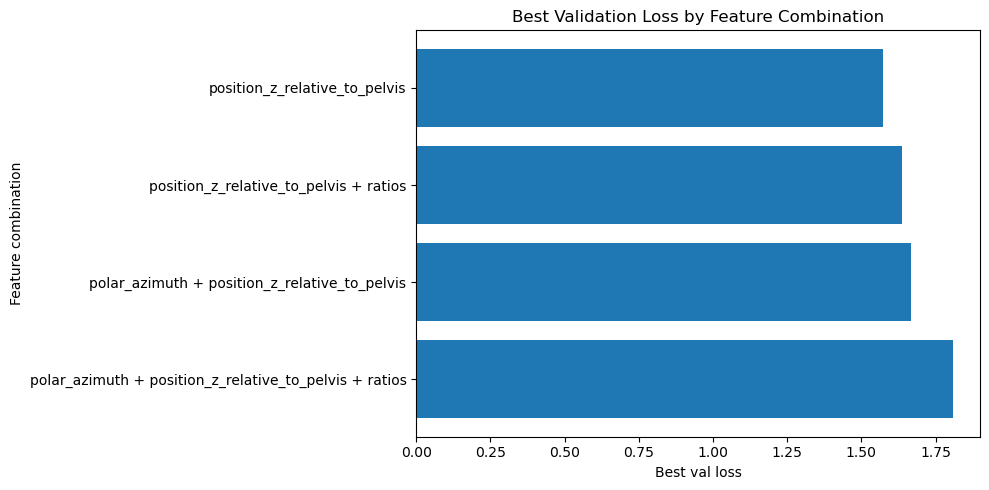

In [4]:
def plot_best_metric(summary_df, metric_col, title, ylabel, ascending=True):
    df = summary_df.sort_values(metric_col, ascending=ascending)

    plt.figure(figsize=(10, 5))
    plt.barh(df["features"], df[metric_col])
    plt.xlabel(ylabel)
    plt.ylabel("Feature combination")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_best_metric(
    summary_df,
    metric_col="best_val_loss",
    title="Best Validation Loss by Feature Combination",
    ylabel="Best val loss",
    ascending=True
)

## Plot best validation accuracy

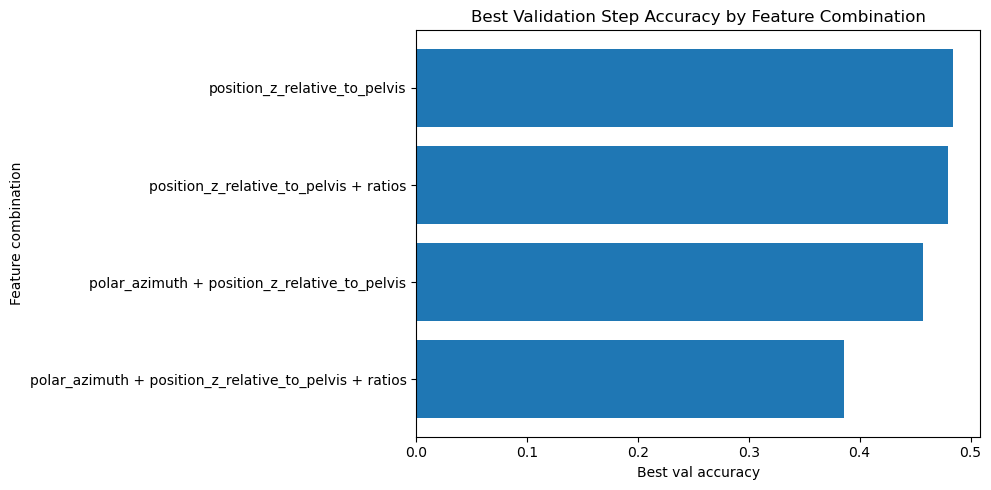

In [5]:
plot_best_metric(
    summary_df,
    metric_col="best_val_acc",
    title="Best Validation Step Accuracy by Feature Combination",
    ylabel="Best val accuracy",
    ascending=False
)

## Plot train / val loss curves for all experiments

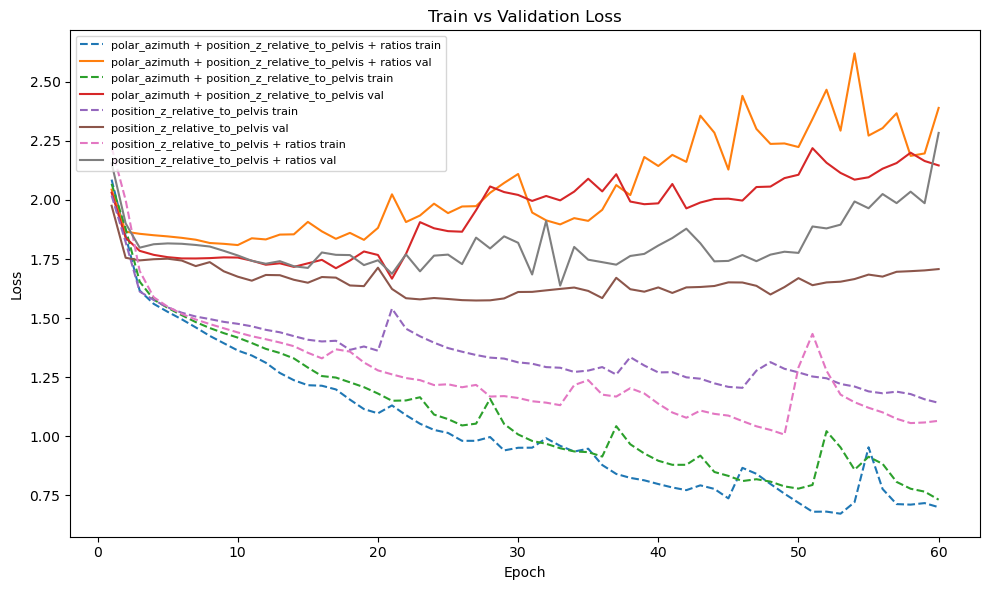

In [6]:
def plot_metric_curves(experiments, train_col, val_col, title, ylabel):
    plt.figure(figsize=(10, 6))

    for exp in experiments:
        metrics = exp["metrics"]
        label = exp["feature_name"]

        plt.plot(metrics["epoch"], metrics[train_col], linestyle="--", label=f"{label} train")
        plt.plot(metrics["epoch"], metrics[val_col], label=f"{label} val")

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_metric_curves(
    experiments,
    train_col="train_loss",
    val_col="val_loss",
    title="Train vs Validation Loss",
    ylabel="Loss"
)

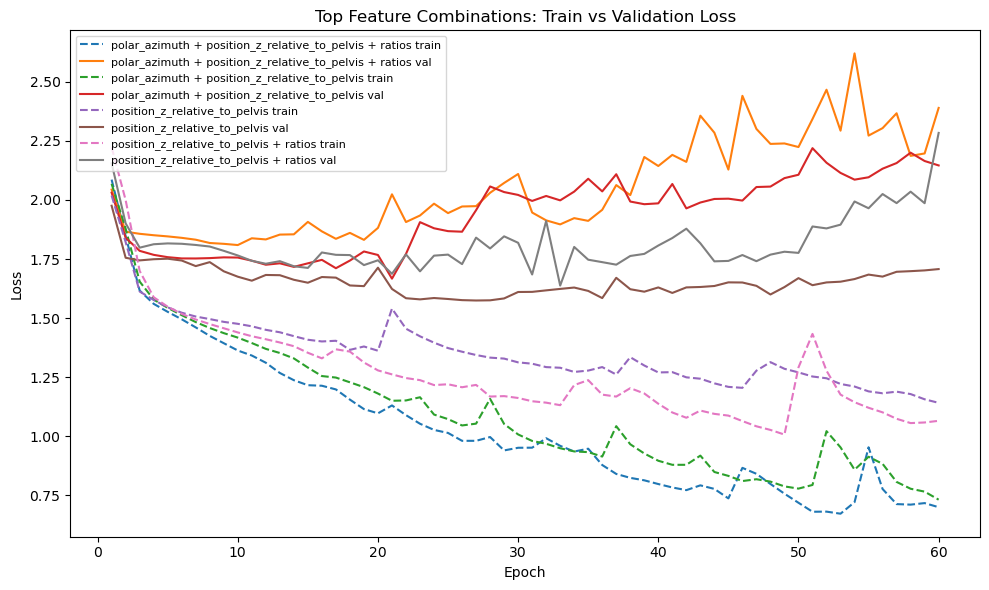

In [8]:
def get_top_experiments(experiments, summary_df, top_n=5, metric_col="best_val_loss"):
    top_names = summary_df.sort_values(metric_col).head(top_n)["run_name"].tolist()
    return [exp for exp in experiments if exp["run_name"] in top_names]


top_experiments = get_top_experiments(experiments, summary_df, top_n=5)

plot_metric_curves(
    top_experiments,
    train_col="train_loss",
    val_col="val_loss",
    title="Top Feature Combinations: Train vs Validation Loss",
    ylabel="Loss"
)

## Plot validation accuracy curves

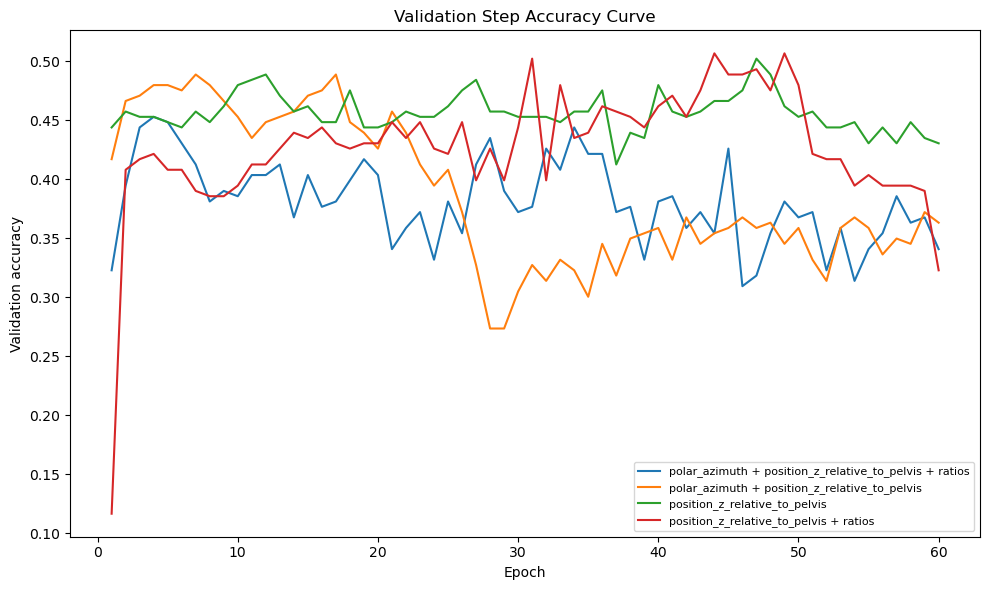

In [9]:
def plot_single_metric_curves(experiments, metric_col, title, ylabel):
    plt.figure(figsize=(10, 6))

    for exp in experiments:
        metrics = exp["metrics"]
        label = exp["feature_name"]

        plt.plot(metrics["epoch"], metrics[metric_col], label=label)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_single_metric_curves(
    top_experiments,
    metric_col="val_acc",
    title="Validation Step Accuracy Curve",
    ylabel="Validation accuracy"
)

## A combined ranking score

In [10]:
rank_df = summary_df.copy()

rank_df["rank_val_loss"] = rank_df["best_val_loss"].rank(ascending=True)
rank_df["rank_val_acc"] = rank_df["best_val_acc"].rank(ascending=False)
rank_df["rank_progress_mae"] = rank_df["best_val_progress_mae"].rank(ascending=True)

rank_df["overall_rank_score"] = (
    rank_df["rank_val_loss"]
    + rank_df["rank_val_acc"]
    + rank_df["rank_progress_mae"]
)

rank_df = rank_df.sort_values("overall_rank_score", ascending=True).reset_index(drop=True)

rank_df[
    [
        "features",
        "best_epoch",
        "best_val_loss",
        "best_val_acc",
        "best_val_progress_mae",
        "overall_rank_score",
    ]
]

,features,best_epoch,best_val_loss,best_val_acc,best_val_progress_mae,overall_rank_score
0,position_z_relative_to_pelvis,27,1.574411,0.484305,0.256779,3.0
1,position_z_relative_to_pelvis + ratios,33,1.637565,0.479821,0.261577,6.0
2,polar_azimuth + position_z_relative_to_pelvis,21,1.666849,0.457399,0.273267,9.0
3,polar_azimuth + position_z_relative_to_pelvis ...,10,1.809104,0.385650,0.275146,12.0


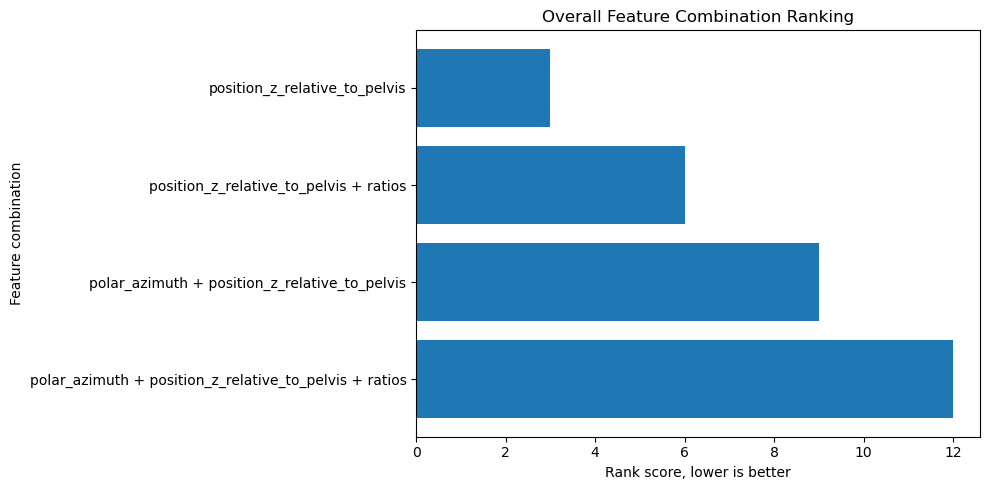

In [11]:
plot_best_metric(
    rank_df,
    metric_col="overall_rank_score",
    title="Overall Feature Combination Ranking",
    ylabel="Rank score, lower is better",
    ascending=True
)